In [2]:
import PeterChurchillFunctions as Function
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.special import erf
import statsmodels.api as sm
from scipy.odr import ODR, Model, RealData
from matplotlib.colors import LogNorm


In [3]:
ECPath = "/share/sabl0586/all_stations_EC-Earth_PRCP2SZDST_ilevall_levs_4Peter.nc"
ds = xr.open_dataset(ECPath, engine="netcdf4")
ds = ds.chunk(time = 1000)
stations = ds["station"].values
TestStation = ['SMR-II']
radii = np.logspace(0, 2.7, 31) #1 to 500 nm RADIUS
VarList = []
IFSVarList = []
x = xr.DataArray(np.logspace(-0.5,3, num=200), dims =['D'], coords= {'D':np.logspace(-0.5,3, num=200)})


In [4]:
ds2 = ds[['RDRY_NUS', 'RDRY_AIS', 'RDRY_ACS', 'RWET_AII', 'RDRY_COS', 'RWET_ACI', 'RWET_COI','N_NUS', 'N_AIS', 'N_ACS', 'N_AII', 'N_COS', 'N_ACI', 'N_COI', 'pressure']]

In [6]:
#ds2 = ds2.where(ds['var54'].isel(lev = 0, lev_ifs= 2).notnull()).dropna('time')

In [8]:
!rm /share/pech2273/EC_Earth_Data.nc
ds2.to_netcdf('/share/pech2273/EC_Earth_Data.nc')


In [11]:
dsIFS = ds[['var20', 'var22','var54']].isel(lev=0).drop_vars('lev').dropna('time')
dsIFS

<xarray.Dataset> Size: 327MB
Dimensions:    (station: 15, time: 19959, lev_ifs: 91)
Coordinates:
  * station    (station) <U8 480B 'ZEP' 'SMR-II' 'ATTO' ... 'Izana' 'Maldives'
  * time       (time) datetime64[ns] 160kB 2012-01-01T03:00:00 ... 2018-12-31...
    time_orig  (time) datetime64[ns] 160kB dask.array<chunksize=(989,), meta=np.ndarray>
  * lev_ifs    (lev_ifs) float64 728B 1.0 2.0 3.0 4.0 ... 88.0 89.0 90.0 91.0
Data variables:
    var20      (station, time, lev_ifs) float32 109MB dask.array<chunksize=(15, 989, 91), meta=np.ndarray>
    var22      (station, time, lev_ifs) float32 109MB dask.array<chunksize=(15, 989, 91), meta=np.ndarray>
    var54      (station, time, lev_ifs) float32 109MB dask.array<chunksize=(15, 989, 91), meta=np.ndarray>

In [39]:
dsIFS.to_netcdf('/share/pech2273/EC_Earth_Data_IFS.nc')


In [15]:
#ds2['pressure'] = ds2['pressure'].mean('time')
dsIFS['pressure'] = dsIFS['var54'].mean('time')
dsIFS = dsIFS.drop_vars('var54')

In [43]:
p_ifs = dsIFS["pressure"]      # (level_ifs, station)
p_tgt = ds2["pressure"]        # (level_tgt=34, station)

In [45]:
print(p_ifs.dims)
print(p_tgt.dims)

('station', 'lev_ifs')
('station', 'lev')


In [47]:
import xarray as xr
p_ifs = dsIFS["pressure"].rename({"lev_ifs": "level_ifs"})
p_tgt = ds2["pressure"].rename({"lev": "level_tgt"})
# Broadcast differences:
# result dims: (level_ifs, level_tgt, station)
diff = abs(
    p_ifs.expand_dims(level_tgt=p_tgt.level_tgt)
    - p_tgt.expand_dims(level_ifs=p_ifs.level_ifs)
)

nearest_idx = diff.argmin(dim="level_ifs")


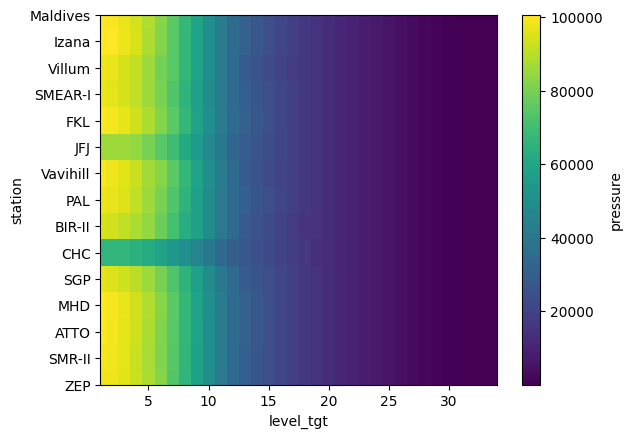

In [54]:
dsIFS_34 = dsIFS.isel(lev_ifs=nearest_idx)
dsIFS_34['pressure'].plot()

In [55]:
dsIFS_34.to_netcdf('/share/pech2273/EC_Earth_Data_IFS_34_levels.nc')

In [52]:

abs(dsIFS_34["pressure"] - p_tgt).max()

<xarray.DataArray 'pressure' ()> Size: 8B
array(4754.0234375)

In [16]:
dsIFS = dsIFS.compute()
ds2 = ds2.compute()
#Define variables for the ERF
radius_variables = ['RDRY_NUS', 'RDRY_AIS', 'RDRY_ACS', 'RWET_AII', 'RDRY_COS', 'RWET_ACI', 'RWET_COI']
Numb_variables = ['N_NUS', 'N_AIS', 'N_ACS', 'N_AII', 'N_COS', 'N_ACI', 'N_COI']
ModesSigma = [1.59, 1.59, 1.59, 2.0, 1.59, 1.59, 2.0]

In [17]:
for radius, number in zip(radius_variables, Numb_variables):
    if radius in ds and number in ds:
        ds2[radius] = ds2[radius]*1e9
        ds2[radius].attrs["units"] = "nm"
        print(f' {radius} added to Dataset')
        ds2[number] = ds2[number]/1e6
        ds2[number].attrs["units"] = "#cm-3"
        print(f' {number} added to Dataset')
    else:
        print(f'{radius, number} not found in EC Path Data')
        


 RDRY_NUS added to Dataset
 N_NUS added to Dataset
 RDRY_AIS added to Dataset
 N_AIS added to Dataset
 RDRY_ACS added to Dataset
 N_ACS added to Dataset
 RWET_AII added to Dataset
 N_AII added to Dataset
 RDRY_COS added to Dataset
 N_COS added to Dataset
 RWET_ACI added to Dataset
 N_ACI added to Dataset
 RWET_COI added to Dataset
 N_COI added to Dataset


In [28]:
ds2 = ds2.drop_vars('lev_ifs')

In [38]:
ds2 


<xarray.Dataset> Size: 570MB
Dimensions:    (station: 15, time: 19959, lev: 34)
Coordinates:
  * lev        (lev) float64 272B 1.0 2.0 3.0 4.0 5.0 ... 31.0 32.0 33.0 34.0
  * station    (station) <U8 480B 'ZEP' 'SMR-II' 'ATTO' ... 'Izana' 'Maldives'
  * time       (time) datetime64[ns] 160kB 2012-01-01T03:00:00 ... 2018-12-31...
    time_orig  (time) datetime64[ns] 160kB 2012-01-01T03:30:00 ... 2018-12-31...
Data variables: (12/15)
    RDRY_NUS   (station, time, lev) float32 41MB 1.581 1.581 ... 1.547 1.451
    RDRY_AIS   (station, time, lev) float32 41MB 15.81 15.81 ... 10.52 6.589
    RDRY_ACS   (station, time, lev) float32 41MB 86.03 84.79 ... 19.36 13.63
    RWET_AII   (station, time, lev) float32 41MB 31.27 31.3 31.31 ... 20.24 10.0
    RDRY_COS   (station, time, lev) float32 41MB 598.3 608.8 ... 2.743 1.448
    RWET_ACI   (station, time, lev) float32 41MB 184.6 184.6 ... 12.27 8.387
    ...         ...
    N_ACS      (station, time, lev) float32 41MB 36.23 31.51 ... 0.0001846
    N_AII      (station, time, lev) float32 41MB 19.01 18.56 ... 2.276e-07
    N_COS      (station, time, lev) float32 41MB 0.6141 0.5032 ... 1.288e-05
    N_ACI      (station, time, lev) float32 41MB 0.4329 0.4252 ... 1.087e-09
    N_COI      (station, time, lev) float32 41MB 0.001699 0.001677 ... 1.723e-08
    pressure   (station, lev) float32 2kB 9.947e+04 9.832e+04 ... 48.79 10.71

In [33]:
print(dsIFS)

<xarray.Dataset> Size: 327MB
Dimensions:    (station: 15, time: 19959, lev_ifs: 91)
Coordinates:
  * station    (station) <U8 480B 'ZEP' 'SMR-II' 'ATTO' ... 'Izana' 'Maldives'
  * time       (time) datetime64[ns] 160kB 2012-01-01T03:00:00 ... 2018-12-31...
    time_orig  (time) datetime64[ns] 160kB 2012-01-01T03:30:00 ... 2018-12-31...
  * lev_ifs    (lev_ifs) float64 728B 1.0 2.0 3.0 4.0 ... 88.0 89.0 90.0 91.0
Data variables:
    var20      (station, time, lev_ifs) float32 109MB 0.0 0.0 ... -2.708e-09
    var22      (station, time, lev_ifs) float32 109MB 0.0 0.0 ... -2.036e-12
    var54      (station, time, lev_ifs) float32 109MB 0.9994 2.989 ... 1.013e+05
    pressure   (station, lev_ifs) float32 5kB 0.9994 2.989 ... 1.009e+05


In [35]:
if ds2.pressure[:, 0].values[0] > ds2.pressure[:, 0].values[-1]:
    ds2_asc = ds2.isel(lev=slice(None, None, -1))
else:
    ds2_asc = ds2

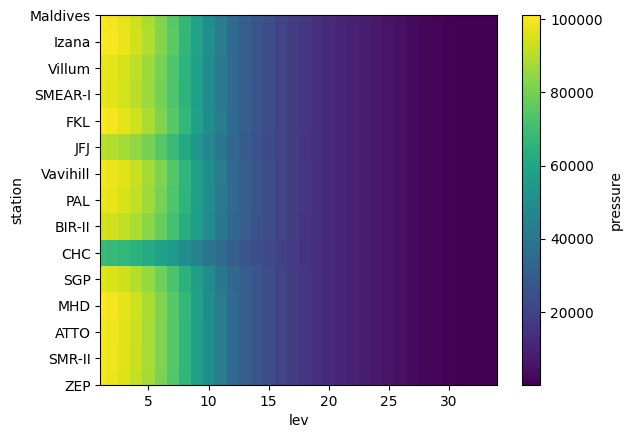

In [37]:
ds2_asc['pressure'].plot()

In [5]:
IFSPressure = ds['var54'].isel(lev = 1).dropna('time')
Pressure = ds['pressure'].where(ds['var54'].isel(lev = 1).notnull()).dropna('time')
Pressure = Pressure.isel(lev_ifs = 1)
Pressure = Pressure.mean('time')
IFSPressure = IFSPressure.mean('time')

In [13]:
dsIFS = IFSPressure.compute()

Pressure = Pressure.compute()
#Pressure = Pressure.drop_vars('lev_ifs')

In [62]:
IFSPressure

<xarray.DataArray 'var54' (station: 15, lev_ifs: 91)> Size: 5kB
array([[9.9939042e-01, 2.9885423e+00, 5.6804962e+00, ..., 9.7354188e+04,
        9.7743211e+04, 9.8024438e+04],
       [9.9939042e-01, 2.9885423e+00, 5.6804962e+00, ..., 9.8582547e+04,
        9.8976789e+04, 9.9261547e+04],
       [9.9939042e-01, 2.9885423e+00, 5.6804962e+00, ..., 9.9249492e+04,
        9.9646531e+04, 9.9933266e+04],
       ...,
       [9.9939042e-01, 2.9885423e+00, 5.6804962e+00, ..., 9.9109539e+04,
        9.9506000e+04, 9.9792320e+04],
       [9.9939042e-01, 2.9885423e+00, 5.6804962e+00, ..., 9.9669133e+04,
        1.0006796e+05, 1.0035588e+05],
       [9.9939042e-01, 2.9885423e+00, 5.6804962e+00, ..., 1.0019979e+05,
        1.0060088e+05, 1.0089036e+05]], shape=(15, 91), dtype=float32)
Coordinates:
  * station  (station) <U8 480B 'ZEP' 'SMR-II' 'ATTO' ... 'Izana' 'Maldives'
  * lev_ifs  (lev_ifs) float64 728B 1.0 2.0 3.0 4.0 5.0 ... 88.0 89.0 90.0 91.0

In [63]:
Pressure

<xarray.DataArray 'pressure' (station: 15, lev: 34)> Size: 2kB
array([[9.94744922e+04, 9.83193672e+04, 9.60196094e+04, 9.24706641e+04,
        8.75613750e+04, 8.13909766e+04, 7.41724609e+04, 6.61935000e+04,
        5.77862383e+04, 4.93805273e+04, 4.15639336e+04, 3.47528242e+04,
        2.97989375e+04, 2.63483926e+04, 2.32618457e+04, 2.05046250e+04,
        1.80450332e+04, 1.58542773e+04, 1.39062148e+04, 1.21759912e+04,
        1.06318184e+04, 9.23577441e+03, 7.95585205e+03, 6.77061914e+03,
        5.43181836e+03, 4.01106177e+03, 2.82526855e+03, 1.87765173e+03,
        1.16055579e+03, 6.54312866e+02, 3.27658813e+02, 1.40404434e+02,
        4.87902985e+01, 1.07069387e+01],
       [9.98917422e+04, 9.87310547e+04, 9.64189688e+04, 9.28494922e+04,
        8.79109844e+04, 8.17034922e+04, 7.44418594e+04, 6.64161953e+04,
        5.79614141e+04, 4.95106250e+04, 4.16550938e+04, 3.48133047e+04,
        2.98394746e+04, 2.63769023e+04, 2.32810293e+04, 2.05168477e+04,
        1.80522871e+04, 1.58582148e+04, 1.39081182e+04, 1.21767764e+04,
        1.06320879e+04, 9.23583789e+03, 7.95587012e+03, 6.77061914e+03,
        5.43181836e+03, 4.01106177e+03, 2.82526855e+03, 1.87765173e+03,
        1.16055579e+03, 6.54312866e+02, 3.27658813e+02, 1.40404434e+02,
        4.87902985e+01, 1.07069387e+01],
       [9.99217812e+04, 9.87606875e+04, 9.64477031e+04, 9.28767969e+04,
        8.79361406e+04, 8.17259766e+04, 7.44612266e+04, 6.64322109e+04,
...
        1.16055579e+03, 6.54312866e+02, 3.27658813e+02, 1.40404434e+02,
        4.87902985e+01, 1.07069387e+01],
       [1.01168055e+05, 9.99904062e+04, 9.76405000e+04, 9.40083438e+04,
        8.89803906e+04, 8.26594219e+04, 7.52658906e+04, 6.70973828e+04,
        5.84972383e+04, 4.99085508e+04, 4.19339141e+04, 3.49983125e+04,
        2.99634824e+04, 2.64640977e+04, 2.33397207e+04, 2.05542363e+04,
        1.80744961e+04, 1.58702656e+04, 1.39139336e+04, 1.21791885e+04,
        1.06329219e+04, 9.23601660e+03, 7.95589600e+03, 6.77061914e+03,
        5.43181836e+03, 4.01106177e+03, 2.82526855e+03, 1.87765173e+03,
        1.16055579e+03, 6.54312866e+02, 3.27658813e+02, 1.40404434e+02,
        4.87902985e+01, 1.07069387e+01],
       [1.00695719e+05, 9.95243047e+04, 9.71884062e+04, 9.35794766e+04,
        8.85846094e+04, 8.23056250e+04, 7.49609219e+04, 6.68452734e+04,
        5.82989297e+04, 4.97612695e+04, 4.18307070e+04, 3.49298398e+04,
        2.99175879e+04, 2.64318301e+04, 2.33180059e+04, 2.05404004e+04,
        1.80662773e+04, 1.58658066e+04, 1.39117783e+04, 1.21782988e+04,
        1.06326230e+04, 9.23599023e+03, 7.95589258e+03, 6.77061914e+03,
        5.43181836e+03, 4.01106177e+03, 2.82526855e+03, 1.87765173e+03,
        1.16055579e+03, 6.54312866e+02, 3.27658813e+02, 1.40404434e+02,
        4.87902985e+01, 1.07069387e+01]], dtype=float32)
Coordinates:
  * lev      (lev) float64 272B 1.0 2.0 3.0 4.0 5.0 ... 30.0 31.0 32.0 33.0 34.0
  * station  (station) <U8 480B 'ZEP' 'SMR-II' 'ATTO' ... 'Izana' 'Maldives'

In [61]:
import numpy as np
import xarray as xr

Pressure_IFS_34 = xr.DataArray(
    data=np.full((len(Pressure.lev), len(stations)), np.nan),
    dims=("lev", "station"),
    coords={
        "lev": Pressure.lev,
        "station": stations,
    },
    name="Pressure_IFS_34",
)


for s in range(len(stations)):
    StationPressure = IFSPressure.isel(station=s).interp(
        IFSPressure=Pressure.isel(station=s).values
    )

    Pressure_IFS_34[:,s] = StationPressure.values

ValueError: Dimensions {'IFSPressure'} do not exist. Expected one or more of FrozenMappingWarningOnValuesAccess({'lev_ifs': 91})

In [55]:
Pressure_IFS_34.sel(station = 'CHC')
#IFSPressure.plot()
Pressure = Pressure.sortby(Pressure['pressure'])
IFSPressure = IFSPressure()
Pressure.plot()

#Pressure.sel(station = 'CHC')

KeyError: 'pressure'

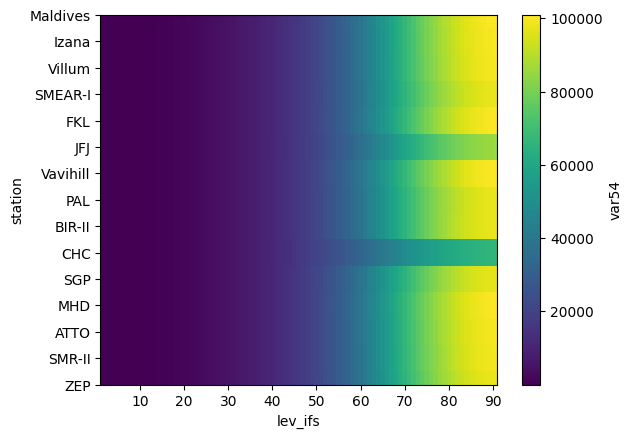

In [53]:
#Pressure.plot()
IFSPressure.plot()

In [71]:
dsIFS

<xarray.Dataset> Size: 218MB
Dimensions:    (station: 15, time: 19959, lev_ifs: 91)
Coordinates:
  * station    (station) <U8 480B 'ZEP' 'SMR-II' 'ATTO' ... 'Izana' 'Maldives'
  * time       (time) datetime64[ns] 160kB 2012-01-01T03:00:00 ... 2018-12-31...
    time_orig  (time) datetime64[ns] 160kB dask.array<chunksize=(1000,), meta=np.ndarray>
  * lev_ifs    (lev_ifs) float64 728B 1.0 2.0 3.0 4.0 ... 88.0 89.0 90.0 91.0
Data variables:
    var20      (station, time, lev_ifs) float32 109MB dask.array<chunksize=(15, 1000, 91), meta=np.ndarray>
    var22      (station, time, lev_ifs) float32 109MB dask.array<chunksize=(15, 1000, 91), meta=np.ndarray>

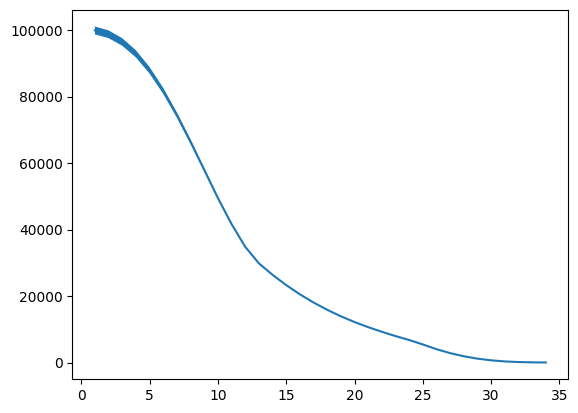

In [46]:
plt.plot(Pressure['lev'], Pressure.mean('time').isel(lev_ifs = 1))
plt.fill_between(Pressure['lev'],
                 Pressure.mean('time').isel(lev_ifs = 1) + Pressure.std('time').isel(lev_ifs = 1),
                 Pressure.mean('time').isel(lev_ifs = 1) - Pressure.std('time').isel(lev_ifs = 1),
                 )
#plt.plot(IFSPressure.isel(time = 2999), Pressure['lev_ifs'])
plt.show()

In [ ]:
def CCN_CDNC(CCN_ds, CDNC_da):
    """
    Compute OLS slope/intercept between CCN(radius, lev, time)
    and CDNC(lev, time) across 'time'.
    """
    CCN_aligned, CDNC_aligned = xr.align(CCN_ds, CDNC_da)

    ds_out = xr.Dataset(
        data_vars={
            'CCN': CCN_aligned,       # dims: (radius, lev, time)
            'CDNC': CDNC_aligned      # dims: (lev, time)
        },
        coords={
            'radius': CCN_aligned.radius,
            'lev': CCN_aligned.lev,
            'time': CCN_aligned.time
        }
    )

    return ds_out


In [ ]:
def ECearthExtract_Dask(ECPath, station):#, chunks="auto"):
    """
    Lazily load EC-Earth data using Dask and optionally compute PNSD.

    Parameters
    ----------
    ECPath : str
        Path to EC-Earth NetCDF file.
    station : str
        Station name or coordinate.
    chunks : str or dict, optional
        Dask chunking specification. Default 'auto'.
    """

    import xarray as xr

    #Open lazily with Dask
    Data = xr.open_dataset(ECPath, engine="netcdf4")#, chunks=chunks)
    Data = Data.sel(station=station)

    ds = xr.Dataset()
    PNSD_ds = xr.Dataset()
    cdnc = xr.Dataset()
    ds_IFS = xr.Dataset()


    #Define variables for the ERF
    radius_variables = ['RDRY_NUS', 'RDRY_AIS', 'RDRY_ACS', 'RWET_AII', 'RDRY_COS', 'RWET_ACI', 'RWET_COI']
    Numb_variables = ['N_NUS', 'N_AIS', 'N_ACS', 'N_AII', 'N_COS', 'N_ACI', 'N_COI']
    ModesSigma = [1.59, 1.59, 1.59, 2.0, 1.59, 1.59, 2.0]
    
    for radius, number in zip(radius_variables, Numb_variables):
        if radius in Data and number in Data:
            ds[radius] = Data[radius]*1e9
            ds[radius].attrs["units"] = "nm"
            #print(f' {radius} added to Dataset')
            ds[number] = Data[number]/1e6
            ds[number].attrs["units"] = "#cm-3"
            #print(f' {number} added to Dataset')
        else:
            print(f'{radius, number} not found in EC Path Data')
            
    # ADD PRESSURE TO DATASET        
    ds['pressure'] = Data['pressure']
    ds['lev'] = ds['pressure'].mean('time')
    ds['lev'] = ds['lev'] / 100
    ds["lev"].attrs["units"] = "hPa"
    #Converting the IFS levels to match the EC-Earth Levs
    for ifs in [['var20', 'var22', 'var54']]:
        ds_IFS[ifs] = Data[ifs]
    ds_IFS = ds_IFS[['var20', 'var22', 'var54']].isel(lev=0).drop_vars('lev')
    ds_IFS['lev_ifs'] = ds_IFS['var54'].mean('time')

    
    return ds, ds_IFS

In [ ]:
# Open dataset to access pressure metadata and data lazily
Pressure_ds = xr.open_dataset(ECPath, engine="netcdf4")

# Extract the pressure variable (do not load all data yet)
Pressure = Pressure_ds["pressure"]

# Compute the mean pressure across time and stations
# This gives you a 1D array of 34 levels
Pressure_mean_levs = Pressure.mean(dim=["time", "station"])#.load()

# Optionally, convert to hPa
Pressure_mean_levs = Pressure_mean_levs / 100
Pressure_mean_levs.attrs["units"] = "hPa"

# Check result
print("Mean pressure levels:", Pressure_mean_levs.shape)
Pressure_mean_levs

In [ ]:
CCN_CDNC_all_ls = []

for station in TestStation:
    print(station)
    EC_ds, ds_ifs = ECearthExtract_Dask(ECPath, station)#, chunks={
        #'station': -1,
        #'time': 1000,
        #'lev': -1
        #})

    # Rename and align IFS dataset
    ds_IFS = ds_ifs.rename({'lev_ifs': 'lev'})
    ds_IFS = ds_IFS.assign_coords(lev=ds_IFS['lev'])
    
    # Interpolate to global mean pressure levels (hPa → Pa)
    ds_ifs_interp = ds_IFS.interp(lev=Pressure_mean_levs * 100)  # back to Pa for consistency
    EC_ds_interp = EC_ds.interp(lev=Pressure_mean_levs * 100)
    # Compute CDNC
    cdnc = (ds_ifs_interp["var20"] / ds_ifs_interp["var22"]).where(ds_ifs_interp["var22"] > 0)
    cdnc['lev'] = Pressure_mean_levs
    cdnc["lev"].attrs["units"] = "hPa"

    # Calculate CCN by radius
    CCN_ds = Function.ECEarthERF(EC_ds_interp, radii)

    # Align CCN and CDNC
    CCN_aligned, CDNC_aligned = xr.align(CCN_ds, cdnc)

    # Build dataset
    CCN_CDNC_ds = xr.Dataset(
        data_vars={
            'CCN': CCN_aligned,
            'CDNC': CDNC_aligned
        },
        coords={
            'radius': CCN_aligned.radius,
            'lev': Pressure_mean_levs,
            'time': CCN_aligned.time
        }
    )

    CCN_CDNC_all_ls.append(CCN_CDNC_ds.assign_coords(station=station))

# Concatenate across stations
CCN_CDNC_all_ds = xr.concat(CCN_CDNC_all_ls, dim='station')

# Chunk for performance
#CCN_CDNC_all_ds = CCN_CDNC_all_ds.chunk({
#    'station': -1,
#    'radius': -1,
#    'time': 1000,
#    'lev': -1
#})

# Persist in memory
#CCN_CDNC_all_ds = CCN_CDNC_all_ds



In [ ]:
print("Unique levs:", len(np.unique(CCN_CDNC_all_ds.lev.values)))

In [ ]:
CCN_CDNC_all_ds['CDNC'].mean('time')

In [ ]:
all_stations = []
all_stationsCCN = []
for station in stations:
    print(station)
    CCN_ds = CCN_CDNC_all_ds['CCN'].sel(station = station)
    cdnc = CCN_CDNC_all_ds['CDNC'].sel(station = station)
    # Caculate the Susceptibilility
    Level_susc_ds, Levels_CCN_ds = Suceptibility_by_Level(CCN_ds, cdnc)
    Susceptibility_AllLevs = compute_allLev(CCN_ds, cdnc)
    
    Susceptibility_ds = xr.merge([Level_susc_ds, Susceptibility_AllLevs])
    
    all_stations.append(Susceptibility_ds.assign_coords(station=station))
    all_stationsCCN.append(Levels_CCN_ds.assign_coords(station=station))

# Concatenate across stations
Susceptibility_all = xr.concat(all_stations, dim='station')
CCN_all = xr.concat(all_stationsCCN, dim='station')

In [ ]:
def PLOTSusc_by_Level(ds = Susceptibility_all, Fit = 'OLS', station = 'SMR-II'):
    radii_to_plot = [20, 30, 40, 50]
    for r in radii_to_plot:
        ds[f'{Fit} slope'].sel(radius=r, station = station).plot(
            y='lev', 
            yincrease=False, 
            ylim=[1000, 600],
            xlim = [0,1],
            label=f'radius={r} nm'
        )
    
    plt.legend()
    plt.xlabel("Susceptibility")
    plt.ylabel("Pressure Level [hPa]")
    plt.title(f"Susceptibility ({Fit}) with height for selected cutoff radii")
    plt.show()

FitType = ['OLS', 'ODR', 'Deming', 'PCA']
for fit in FitType:
    print(fit)
    PLOTSusc_by_Level(Susceptibility_all, Fit = fit, station = 'ATTO')

In [ ]:
stations = Susceptibility_all.station.values
methods = ["OLS", "TLS", "Deming", "PCA"]

# Define number of columns and rows dynamically
ncols = 4
nrows = int(np.ceil(len(stations) / ncols))

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(5 * ncols, 4 * nrows),
    sharey=True
)

axes = axes.flatten()

for i, station in enumerate(stations):
    ax = axes[i]
    for method in methods:
        var_name = f"All_Level_{method}_slope"
        if var_name in Susceptibility_all:
            Susceptibility_all[var_name].sel(station=station).plot(
                ax=ax, marker='x', label=method
            )
    ax.set_title(f"{station}", fontsize=11)
    ax.set_xlabel("Cutoff Radius (nm)")
    ax.set_ylabel("Susceptibility (slope)")
    ax.set_ylim(0, 2)
    ax.grid(True, alpha=0.3)

# Hide any unused subplots
for j in range(len(stations), len(axes)):
    axes[j].set_visible(False)

# Add a global legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Method", loc="lower right", fontsize=20)

fig.suptitle("All-level CCN–CDNC Susceptibility per Station", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


In [ ]:
def plot_station_fits_from_dataset(Susceptibility_all, station, CCN_ds, EC_ds, radius=35, methods=None):
    """
    Plot Nd vs CCN (log–log) with precomputed fits from Susceptibility_all.
    No refitting is done here.
    """
    if methods is None:
        methods = ["OLS", "TLS", "Deming", "PCA"]

    # --- Prepare data ---
    x = CCN_all['CCN'].sel(radius=radius, station = station).to_numpy().ravel()
    y = CCN_all["CDNC"].sel(station = station).to_numpy().ravel()

    mask = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
    x, y = x[mask], y[mask]

    fits = []

    # --- Get slopes/intercepts from dataset ---
    for method in methods:
        slope_var = f"All_Level_{method}_slope"
        intercept_var = f"All_Level_{method}_intercept"

        if slope_var in Susceptibility_all and intercept_var in Susceptibility_all:
            slope = Susceptibility_all[slope_var].sel(station=station, radius=radius).compute().item()
            intercept = Susceptibility_all[intercept_var].sel(station=station, radius=radius).compute().item()

            fits.append({
                "slope": slope,
                "intercept": intercept,
                "label": f"{method}: slope={slope:.2f}",
                "style": {
                    "OLS": "r-",
                    "TLS": "g--",
                    "Deming": "b-.",
                    "PCA": "m:",
                }.get(method, "k-")
            })

    # --- Plot all fits on a single hexbin plot ---
    fig, ax = Function.plot_hexbin_regression_multi(
        x, y,
        fits=fits,
        lims=(1, 1e4),
        title=f"{station}: CCN–CDNC Fits (radius={radius} nm)"
    )

    plt.tight_layout()
    return fig, ax

In [ ]:
for station in stations:
    plot_station_fits_from_dataset(
        Susceptibility_all,
        station=station,
        CCN_ds=CCN_ds,
        EC_ds=EC_ds,
        radius=35
    )

In [ ]:
def PNSD_ECearth(PNSD, Data):       
    #Particle Number Size Distribution
    if PNSD:
        # Collect PNSD variables
        for radius, conc in zip(radius_variables, Numb_variables):
            if radius in Data and conc in Data:
                PNSD_ds[radius] = Data[radius]
                PNSD_ds[conc] = Data[conc]

        # Compute distributions lazily with Dask
        dis_variable = ["NUS_dis", "AIS_dis", "ACS_dis", "COS_dis", "AII_dis", "ACI_dis", "COI_dis"]

        for radius, conc, sigma, dist in zip(radius_variables, Numb_variables, ModesSigma, dis_variable):
            if radius not in PNSD_ds or conc not in PNSD_ds:
                continue

            PNSD_ds[dist] = xr.apply_ufunc(
                Function.dNdlogD,
                PNSD_ds[conc],
                Xspace,
                PNSD_ds[radius] * 2,
                sigma,
                dask="parallelized",
                dask_gufunc_kwargs={'allow_rechunk': True},
                output_dtypes=[float],
            )

        # Combine all dNdlogD modes lazily
        dNdlogD_vars = [v for v in PNSD_ds.data_vars if v.endswith("_dis")]
        if len(dNdlogD_vars) > 0:
            PNSD_ds["dNdlogD"] = sum(PNSD_ds[v] for v in dNdlogD_vars)

        return ds, PNSD_ds, cdnc

    else:
        # Return only basic variables
        for radius, conc in zip(radius_variables, Numb_variables):
            if radius in Data:
                ds[radius] = Data[radius]
            if conc in Data:
                ds[conc] = Data[conc]
                
        return ds, cdnc

In [ ]:
Susceptibility_all


In [ ]:
for station in stations:
    print(CCN_all['CDNC'].sel(station = station).mean().values)

In [ ]:
CCN_all['CCN']

In [ ]:
Susceptibility_all['OLS intercept'].isel(station = 1).lev.where(Susceptibility_all['OLS intercept'].isel(station = 1) > 0)


In [ ]:
CCN_CDNC_all_ds['CCN'].sel(station = 'SMR-II', radius = 35).plot()